# Validation Accuracy (Notebook wrapper)

This notebook is a thin wrapper around `modeling/validate_model_accuracy.py` so you can run validation evaluation from the notebook UI.

It writes metrics/plots/predictions to `modeling/results/<TARGET>/validation_eval_<EXPOSURE_SET>__<MODEL_FAMILY>/`.


In [4]:
# ---- Fixed from here on out (per your constraint) ----
# Only Full_pesticides_raw + XGBoost, and no fitting/tuning on validation rows.

TARGETS = ["CASTHMA", "COPD"]
EXPOSURE_SET = "Full_pesticides_raw"
MODEL_FAMILY = "XGBoost (tuned)"
VALIDATION_SET = "external_holdout"  # train split only, evaluate on validation split

# CV is only used *inside the train split* to pick hyperparameters.
CV_SPLITS = 5
BOOTSTRAP_N = 100
RANDOM_STATE = 42

# Optional: where outputs should be written
OUTPUT_DIR = None  # defaults to modeling/results

# Website export (optional)
EXPORT_WEB_JSON = True
WEB_DISPLAY_YEAR = 2019

# Guardrails
assert EXPOSURE_SET == "Full_pesticides_raw"
assert MODEL_FAMILY == "XGBoost (tuned)"
assert VALIDATION_SET == "external_holdout"

print("Running:")
print("  TARGETS      =", TARGETS)
print("  EXPOSURE_SET =", EXPOSURE_SET)
print("  MODEL_FAMILY =", MODEL_FAMILY)
print("  VALIDATION   =", VALIDATION_SET)


Running:
  TARGETS      = ['CASTHMA', 'COPD']
  EXPOSURE_SET = Full_pesticides_raw
  MODEL_FAMILY = XGBoost (tuned)
  VALIDATION   = external_holdout


In [5]:
import subprocess
import sys
from pathlib import Path


REPO_ROOT = Path.cwd()
# If you run this notebook from within `modeling/`, step up one.
if (REPO_ROOT / "model_evaluation.py").exists():
    REPO_ROOT = REPO_ROOT.parent

script_path = REPO_ROOT / "modeling" / "validate_model_accuracy.py"
if not script_path.exists():
    raise FileNotFoundError(f"Could not find script: {script_path}")

OUT_BASE = (REPO_ROOT / "modeling" / "results") if OUTPUT_DIR is None else Path(OUTPUT_DIR)
model_family_safe = MODEL_FAMILY.replace(" ", "_")

out_dirs = {}
for target in TARGETS:
    cmd = [
        sys.executable,
        str(script_path),
        "--target",
        target,
        "--exposure-set",
        EXPOSURE_SET,
        "--model-family",
        MODEL_FAMILY,
        "--validation-set",
        VALIDATION_SET,
        "--cv-splits",
        str(CV_SPLITS),
        "--bootstrap-n",
        str(BOOTSTRAP_N),
        "--random-state",
        str(RANDOM_STATE),
        "--export-all-counties",
    ]
    if OUTPUT_DIR is not None:
        cmd += ["--output-dir", str(OUTPUT_DIR)]

    print("\nCommand:\n", " ".join(cmd))
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.stdout:
        print(proc.stdout)
    if proc.returncode != 0:
        if proc.stderr:
            print(proc.stderr, file=sys.stderr)
        raise subprocess.CalledProcessError(proc.returncode, cmd, output=proc.stdout, stderr=proc.stderr)

    out_dir = OUT_BASE / target / f"validation_eval_{EXPOSURE_SET}__{model_family_safe}"
    out_dirs[target] = out_dir

print("\nOutput dirs:")
for k, v in out_dirs.items():
    print(" ", k, "->", v)



Command:
 /opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/bin/python /Users/allisonlonderee/Desktop/repos/spring-2026-pesticide-exposure/modeling/validate_model_accuracy.py --target CASTHMA --exposure-set Full_pesticides_raw --model-family XGBoost (tuned) --validation-set external_holdout --cv-splits 5 --bootstrap-n 100 --random-state 42 --export-all-counties
Wrote external holdout validation evaluation to: /Users/allisonlonderee/Desktop/repos/spring-2026-pesticide-exposure/modeling/results/CASTHMA/validation_eval_Full_pesticides_raw__XGBoost_(tuned)


Command:
 /opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/bin/python /Users/allisonlonderee/Desktop/repos/spring-2026-pesticide-exposure/modeling/validate_model_accuracy.py --target COPD --exposure-set Full_pesticides_raw --model-family XGBoost (tuned) --validation-set external_holdout --cv-splits 5 --bootstrap-n 100 --random-state 42 --export-all-counties
Wrote external holdout validation evaluation to: 

In [6]:
import pandas as pd

rows = []
for target, out_dir in out_dirs.items():
    metrics_path = out_dir / "metrics.csv"
    if not metrics_path.exists():
        raise FileNotFoundError(f"Metrics file not found: {metrics_path}")
    rows.append(pd.read_csv(metrics_path))

metrics_all = pd.concat(rows, ignore_index=True)
metrics_all


,target,exposure_set,model,validation_mode,rmse,mae,r2,rmse_ci_low,rmse_ci_high,n_rows,best_params_str
0,CASTHMA,Full_pesticides_raw,XGBoost (tuned),external_holdout,0.388824,0.287181,0.835372,0.365812,0.409747,1219,"{'model__learning_rate': 0.1, 'model__max_dept..."
1,COPD,Full_pesticides_raw,XGBoost (tuned),external_holdout,0.764964,0.574382,0.885378,0.728426,0.803020,1219,"{'model__learning_rate': 0.05, 'model__max_dep..."


In [7]:
# Optional: show the first few prediction rows per target
from IPython.display import display
import pandas as pd

for target, out_dir in out_dirs.items():
    pred_files = sorted(list(out_dir.glob("predictions_*.csv")))
    print("\n", target)
    print("  Prediction files:", [p.name for p in pred_files])
    if pred_files:
        display(pd.read_csv(pred_files[0]).head())



 CASTHMA
  Prediction files: ['predictions_all_counties.csv', 'predictions_validation_holdout.csv']


,FIPS,YEAR,NAME,state_fips,actual,prediction,residual
0,1001,2018,"Autauga County, Alabama",1,10.2,10.202633,-0.002633
1,1001,2019,"Autauga County, Alabama",1,9.7,9.544121,0.155879
2,1003,2018,"Baldwin County, Alabama",1,9.5,9.418329,0.081671
3,1003,2019,"Baldwin County, Alabama",1,8.8,8.853751,-0.053751
4,1007,2018,"Bibb County, Alabama",1,10.3,10.340404,-0.040404



 COPD
  Prediction files: ['predictions_all_counties.csv', 'predictions_validation_holdout.csv']


,FIPS,YEAR,NAME,state_fips,actual,prediction,residual
0,1001,2018,"Autauga County, Alabama",1,7.7,8.351712,-0.651712
1,1001,2019,"Autauga County, Alabama",1,8.4,7.650614,0.749386
2,1003,2018,"Baldwin County, Alabama",1,8.6,8.240267,0.359733
3,1003,2019,"Baldwin County, Alabama",1,8.4,7.913565,0.486435
4,1007,2018,"Bibb County, Alabama",1,10.1,10.396827,-0.296827


In [8]:
# Optional: export *all-county* estimates for the website map
# Produces web/data/validation_map_data.json with the same structure as web/data/xgboost_map_data.json.
#
# IMPORTANT: This does NOT fit on validation rows.
# It uses `predictions_all_counties.csv` written by the script after training on the train split.

import json
import pandas as pd


def min_max_norm(values: list[float]) -> list[float]:
    lo, hi = float(min(values)), float(max(values))
    if hi <= lo:
        return [0.5 for _ in values]
    return [(float(v) - lo) / (hi - lo) for v in values]


if not EXPORT_WEB_JSON:
    print("EXPORT_WEB_JSON=False; skipping.")
else:
    out = {}

    for target, out_dir in out_dirs.items():
        all_path = out_dir / "predictions_all_counties.csv"
        if not all_path.exists():
            raise FileNotFoundError(
                f"Missing {all_path}. Re-run the evaluation cell; it should call the script with --export-all-counties."
            )

        df = pd.read_csv(all_path)
        df = df[df["YEAR"].astype(int) == int(WEB_DISPLAY_YEAR)].copy()
        df["FIPS"] = df["FIPS"].astype(int).astype(str).str.zfill(5)

        key = target.lower() if target.lower() != "casthma" else "casthma"
        preds = df["prediction"].astype(float).tolist()
        risks = min_max_norm(preds)

        for fips, actual, pred, risk in zip(df["FIPS"], df["actual"], df["prediction"], risks):
            if fips not in out:
                out[fips] = {"year": int(WEB_DISPLAY_YEAR)}
            out[fips][key] = {
                "actual": float(actual),
                "prediction": float(pred),
                "risk_index": float(risk),
            }

    web_out = REPO_ROOT / "web" / "data" / "validation_map_data.json"
    web_out.parent.mkdir(parents=True, exist_ok=True)
    with open(web_out, "w", encoding="utf-8") as f:
        json.dump(out, f, indent=0)

    print(f"Wrote {len(out)} counties to {web_out} (year {WEB_DISPLAY_YEAR})")
    print("Open the map with: web/map.html?source=validation")


Wrote 3043 counties to /Users/allisonlonderee/Desktop/repos/spring-2026-pesticide-exposure/web/data/validation_map_data.json (year 2019)
Open the map with: web/map.html?source=validation


## Additional evaluations (mirrors `model_evaluation.ipynb`)

The cells below load the saved validation predictions and run the same diagnostics used in `modeling/model_evaluation.ipynb`:
- Core plots (pred vs actual, residual diagnostics)
- Subgroup error tables (where metadata is available)
- Top-error inspection
- County-level mean absolute error maps (Plotly choropleth)


In [9]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# Ensure repo imports work no matter where notebook runs from
# Walk upwards from CWD until we find the repo root containing `modeling/`.
if "REPO_ROOT" not in globals():
    here = Path.cwd().resolve()
    REPO_ROOT = None
    for p in [here, *here.parents]:
        if (p / "modeling" / "model_evaluation.py").exists():
            REPO_ROOT = p
            break
    if REPO_ROOT is None:
        raise FileNotFoundError(
            "Could not locate repo root (missing modeling/model_evaluation.py). "
            f"Started search from: {here}"
        )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modeling.model_evaluation import evaluate, detect_task  # noqa: E402


def _qsplit(series: pd.Series, *, q: float = 0.5, high_label: str = "high", low_label: str = "low", invert: bool = False) -> np.ndarray:
    s = pd.to_numeric(pd.Series(series), errors="coerce")
    thr = s.quantile(q)
    if invert:
        out = np.where(s <= thr, high_label, low_label)
    else:
        out = np.where(s >= thr, high_label, low_label)
    out[pd.isna(s)] = None
    return out


def _string_labels(s: pd.Series, missing_label: str = "missing") -> np.ndarray:
    out = pd.Series(s).astype("string").fillna(missing_label)
    return out.astype(str).to_numpy()


def load_validation_predictions(out_dir: Path) -> pd.DataFrame:
    p = out_dir / "predictions_validation_holdout.csv"
    if not p.exists():
        raise FileNotFoundError(f"Missing {p}")
    df = pd.read_csv(p)
    if "FIPS" in df.columns:
        df["FIPS"] = df["FIPS"].astype(int)
    if "YEAR" in df.columns:
        df["YEAR"] = df["YEAR"].astype(int)
    return df


def load_all_county_predictions(out_dir: Path) -> pd.DataFrame:
    p = out_dir / "predictions_all_counties.csv"
    if not p.exists():
        raise FileNotFoundError(f"Missing {p}")
    df = pd.read_csv(p)
    if "FIPS" in df.columns:
        df["FIPS"] = df["FIPS"].astype(int)
    if "YEAR" in df.columns:
        df["YEAR"] = df["YEAR"].astype(int)
    return df


def build_subgroup_columns_for_validation(pred_df: pd.DataFrame) -> tuple[dict[str, np.ndarray], pd.DataFrame]:
    """Mirror `model_evaluation.ipynb` subgroup definitions, but for validation rows."""
    data_path = Path(REPO_ROOT) / "data" / "validation.csv"
    if not data_path.exists():
        merged = pred_df.copy()
    else:
        val_df = pd.read_csv(data_path)
        merge_cols = [c for c in ["FIPS", "YEAR"] if c in pred_df.columns and c in val_df.columns]
        merged = pred_df.merge(val_df, on=merge_cols, how="left") if merge_cols else pred_df.copy()

    subgroup_columns: dict[str, np.ndarray] = {}

    # Poverty: prefer explicit poverty_rate; otherwise proxy with median_income.
    if "poverty_rate" in merged.columns:
        subgroup_columns["ej_poverty"] = _string_labels(
            _qsplit(merged["poverty_rate"], high_label="high_poverty", low_label="low_poverty")
        )
    elif "pct_poverty" in merged.columns:
        subgroup_columns["ej_poverty"] = _string_labels(
            _qsplit(merged["pct_poverty"], high_label="high_poverty", low_label="low_poverty")
        )
    elif "median_income" in merged.columns:
        subgroup_columns["ej_poverty"] = _string_labels(
            _qsplit(merged["median_income"], high_label="high_poverty", low_label="low_poverty", invert=True)
        )

    # SVI
    for svi_col in ["SVI", "svi", "svi_total", "svi_overall", "svi_rank"]:
        if svi_col in merged.columns:
            subgroup_columns["ej_svi"] = _string_labels(_qsplit(merged[svi_col], high_label="high_SVI", low_label="low_SVI"))
            break

    # Racial majority: person-centered labels (majority_white vs majority_BIPOC), no default to white.
    if "pct_white" in merged.columns:
        pw = pd.to_numeric(merged["pct_white"], errors="coerce")
        subgroup_columns["ej_racial_majority"] = _string_labels(
            np.where(pw >= 50, "majority_white", "majority_BIPOC")
        )

    # Rural/urban proxy via nchs_urban_rural.
    if "nchs_urban_rural" in merged.columns:
        ur = pd.to_numeric(merged["nchs_urban_rural"], errors="coerce")
        subgroup_columns["ej_rural"] = _string_labels(np.where(ur >= 5, "rural", "urban"))

    # Pesticide use proxy via pesticide_total_kg per cropland acre.
    if "pesticide_total_kg" in merged.columns and "cropland_acres" in merged.columns:
        denom = pd.to_numeric(merged["cropland_acres"], errors="coerce").replace(0, np.nan)
        num = pd.to_numeric(merged["pesticide_total_kg"], errors="coerce")
        per_acre = num / denom
        subgroup_columns["ej_pesticide_use"] = _string_labels(
            _qsplit(per_acre, high_label="high_pesticide_use", low_label="low_pesticide_use")
        )

    # IPM breadth
    if "ipm_breadth_acre" in merged.columns:
        subgroup_columns["ej_ipm_breadth"] = _string_labels(
            _qsplit(merged["ipm_breadth_acre"], high_label="high_ipm_breadth", low_label="low_ipm_breadth")
        )
    elif "ipm_breadth_value" in merged.columns:
        subgroup_columns["ej_ipm_breadth"] = _string_labels(
            _qsplit(merged["ipm_breadth_value"], high_label="high_ipm_breadth", low_label="low_ipm_breadth")
        )

    # Always include a simple place subgroup
    if "state_fips" in merged.columns:
        subgroup_columns["state_fips"] = merged["state_fips"].to_numpy()

    return subgroup_columns, merged


def run_notebook_evaluation(pred_df: pd.DataFrame) -> dict:
    subgroup_columns, merged = build_subgroup_columns_for_validation(pred_df)

    y_true = merged["actual"].to_numpy(dtype=float)
    y_pred = merged["prediction"].to_numpy(dtype=float)

    # Simple “high/low” splits as fallbacks
    subgroup_columns["actual_high"] = _string_labels(_qsplit(merged["actual"], q=0.5))
    subgroup_columns["pred_high"] = _string_labels(_qsplit(merged["prediction"], q=0.5))

    time_column = "YEAR" if "YEAR" in merged.columns else None

    return evaluate(
        y_true,
        y_pred,
        task=detect_task(y_true),
        X_test=merged,
        subgroup_columns=subgroup_columns if subgroup_columns else None,
        time_column=time_column,
        top_n_errors=25,
        min_subgroup_support=10,
    )



Target: CASTHMA
Out dir: /Users/allisonlonderee/Desktop/repos/spring-2026-pesticide-exposure/modeling/results/CASTHMA/validation_eval_Full_pesticides_raw__XGBoost_(tuned)
Validation predictions: (1219, 7)


,FIPS,YEAR,NAME,state_fips,actual,prediction,residual
0,1005,2018,"Barbour County, Alabama",1,11.6,11.614885,-0.014885
1,1005,2019,"Barbour County, Alabama",1,11.0,11.085428,-0.085428
2,1013,2018,"Butler County, Alabama",1,11.4,11.046700,0.353300
3,1013,2019,"Butler County, Alabama",1,10.9,11.021353,-0.121353
4,1015,2018,"Calhoun County, Alabama",1,11.1,10.000319,1.099681



Headline metrics


,metric,value
0,MAE,0.287181
1,RMSE,0.388824
2,R²,0.835372
3,Median AE,0.221749
4,MAPE (%),2.951132



Core diagnostic plots


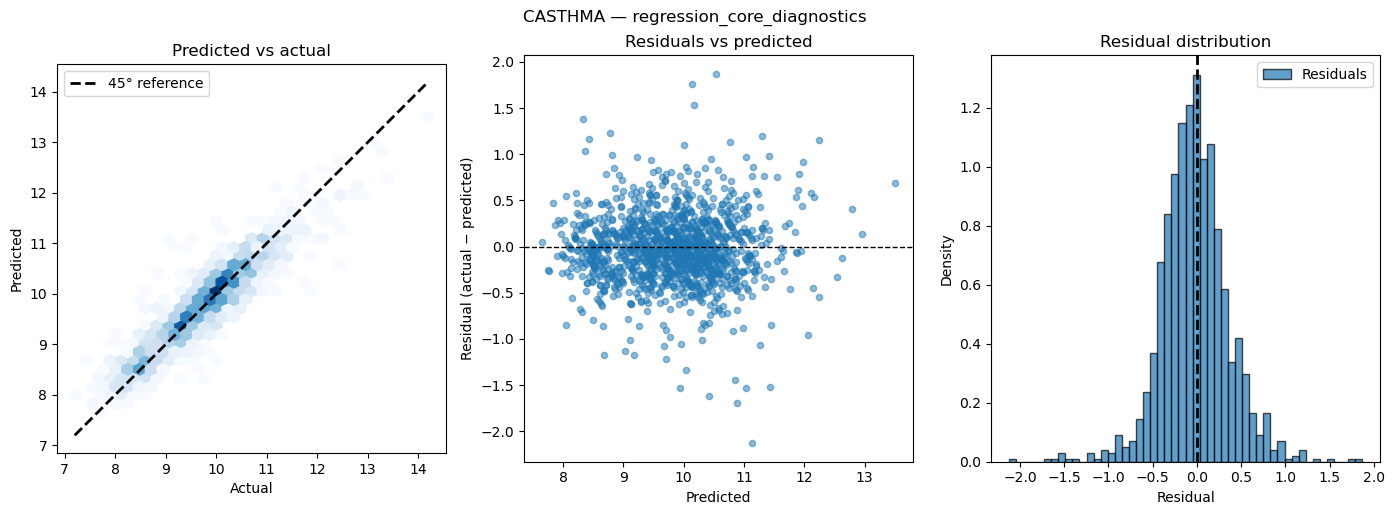

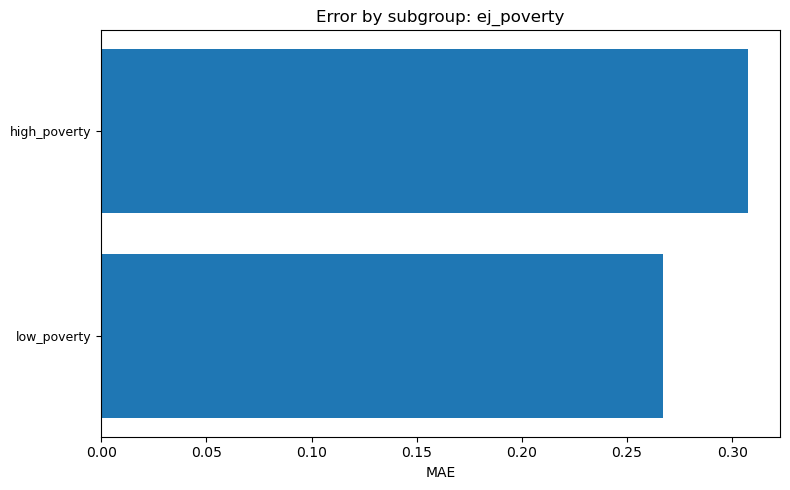

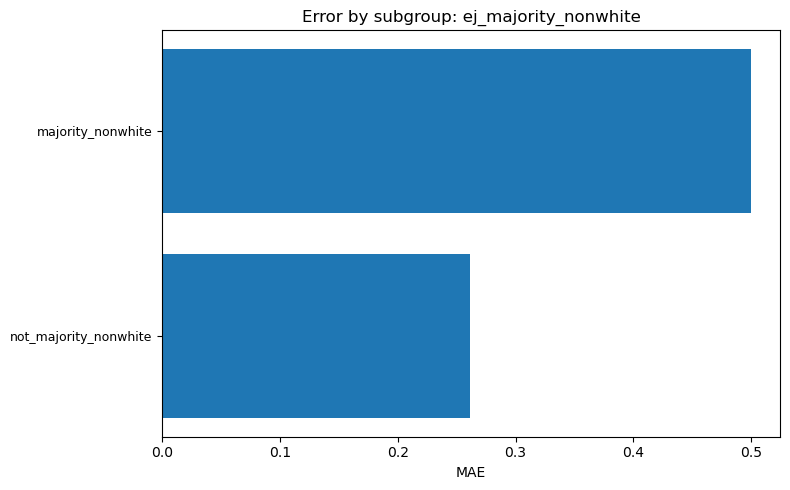

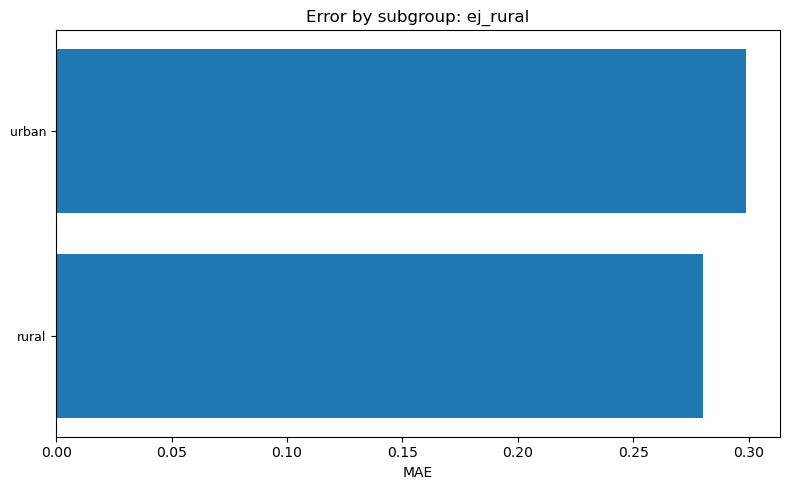

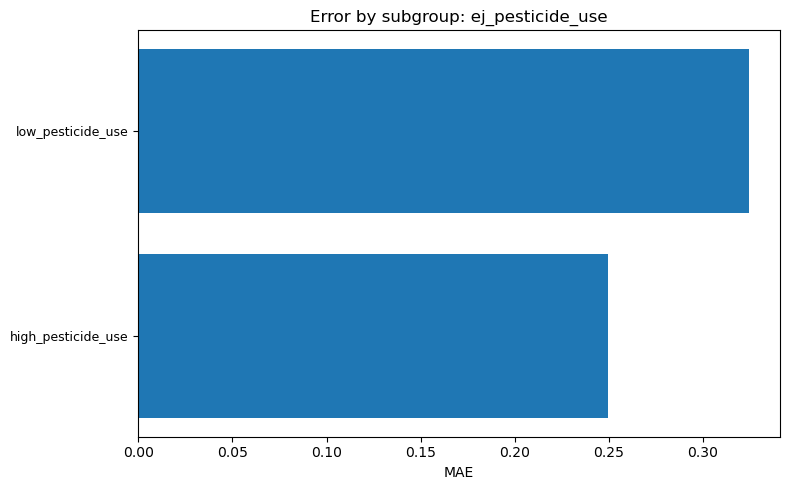

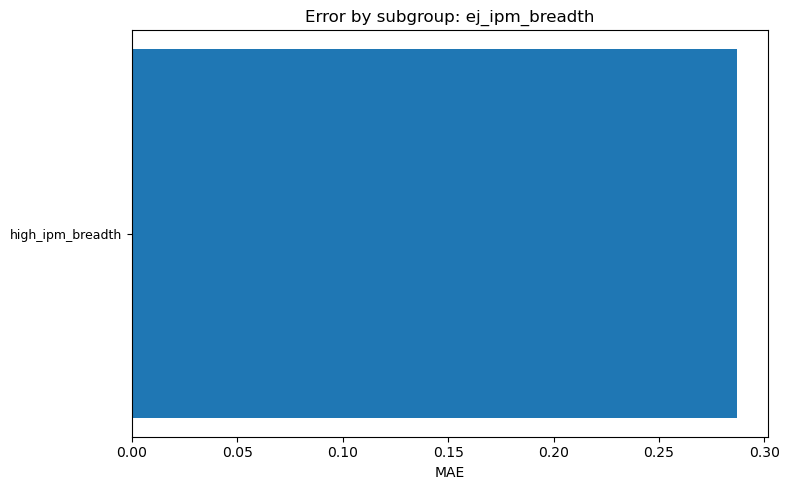

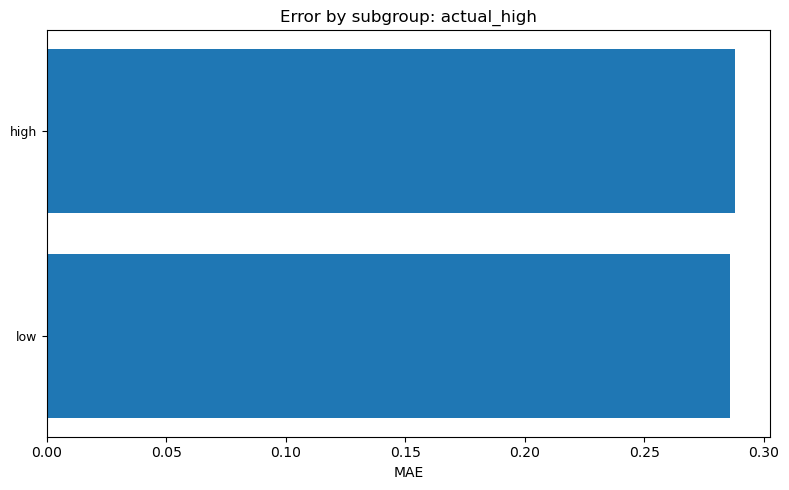

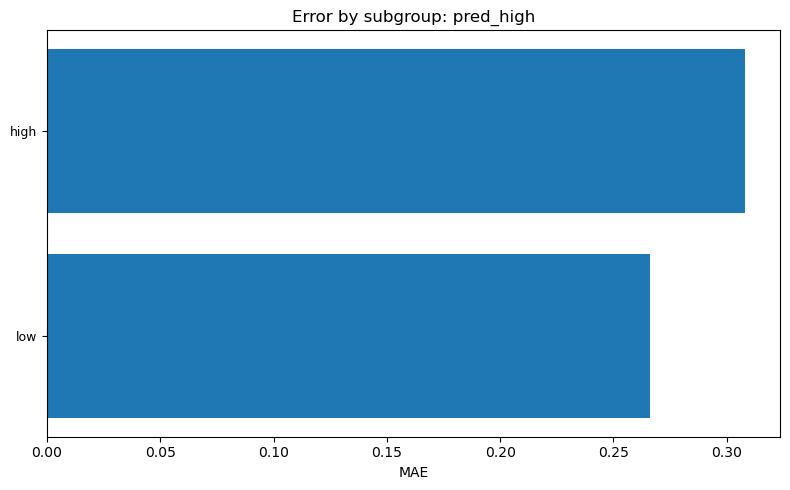

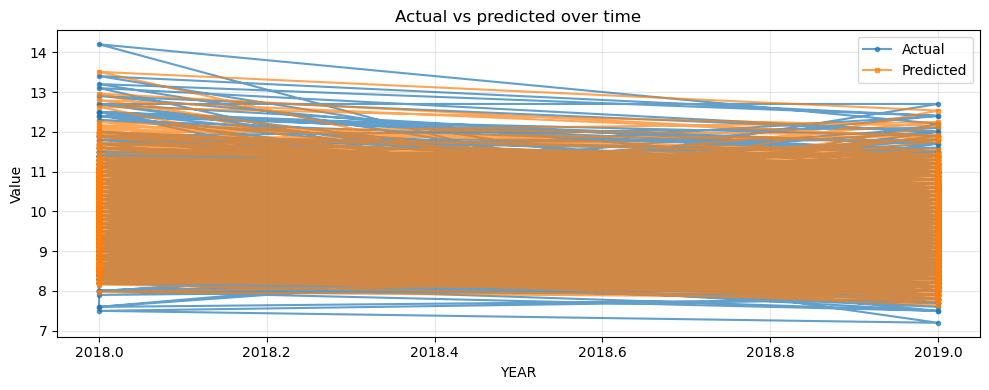


Subgroup performance

Subgroup: ej_poverty


,n,mean_actual,mean_predicted,MAE,RMSE,mean_residual,underprediction_rate,note
group,,,,,,,,
high_poverty,610,10.240328,10.247850,0.307326,0.424757,-0.007522,0.475410,
low_poverty,609,9.306076,9.344869,0.267003,0.349143,-0.038793,0.444992,



Subgroup: ej_majority_nonwhite


,n,mean_actual,mean_predicted,MAE,RMSE,mean_residual,underprediction_rate,note
group,,,,,,,,
majority_nonwhite,131,10.067939,10.093872,0.499454,0.665180,-0.025933,0.465649,
not_majority_nonwhite,1088,9.738143,9.760952,0.261623,0.340752,-0.022809,0.459559,



Subgroup: ej_rural


...


Interpretation
1. Overall: R² = 0.835; RMSE = 0.389, MAE = 0.287. Model explains a substantial share of variance.
2. Bias: Mean residual = -0.023. Residuals are roughly centered.
3. Residuals: Residual spread does not strongly depend on predicted value.
4. Subgroups: Subgroup MAE varies; check tables for groups with high error or low support.
5. Trust: Use metrics, residual plots, and subgroup results to judge whether the model is stable and fair enough for deployment.

Next steps
• Investigate top-error rows for outliers or data issues.
• If heteroskedasticity is present, consider transforms or robust metrics.
• If subgroups differ sharply, consider stratified models or fairness constraints.
• Re-evaluate on a fresh holdout if possible.

Target: COPD
Out dir: /Users/allisonlonderee/Desktop/repos/spring-2026-pesticide-exposure/modeling/results/COPD/validation_eval_Full_pesticides_raw__XGBoost_(tuned)
Validation predictions: (1219, 7)


,FIPS,YEAR,NAME,state_fips,actual,prediction,residual
0,1005,2018,"Barbour County, Alabama",1,12.1,11.961602,0.138398
1,1005,2019,"Barbour County, Alabama",1,10.7,11.261658,-0.561658
2,1013,2018,"Butler County, Alabama",1,11.4,10.655898,0.744102
3,1013,2019,"Butler County, Alabama",1,11.1,10.225099,0.874901
4,1015,2018,"Calhoun County, Alabama",1,10.2,9.615688,0.584312



Headline metrics


,metric,value
0,MAE,0.574382
1,RMSE,0.764964
2,R²,0.885378
3,Median AE,0.438961
4,MAPE (%),7.127147



Core diagnostic plots


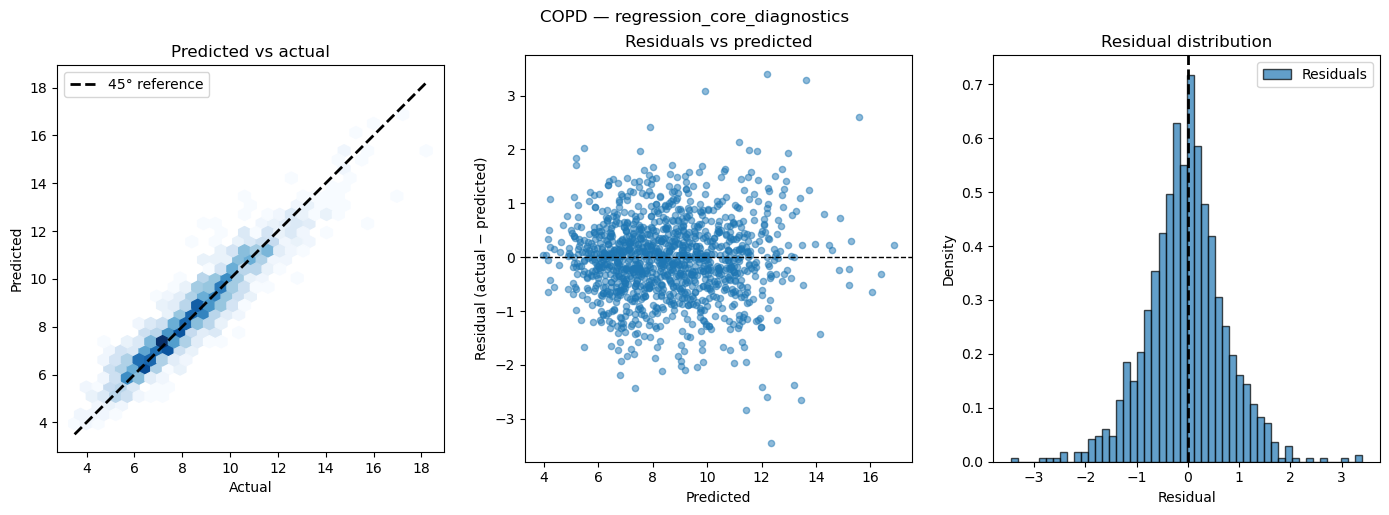

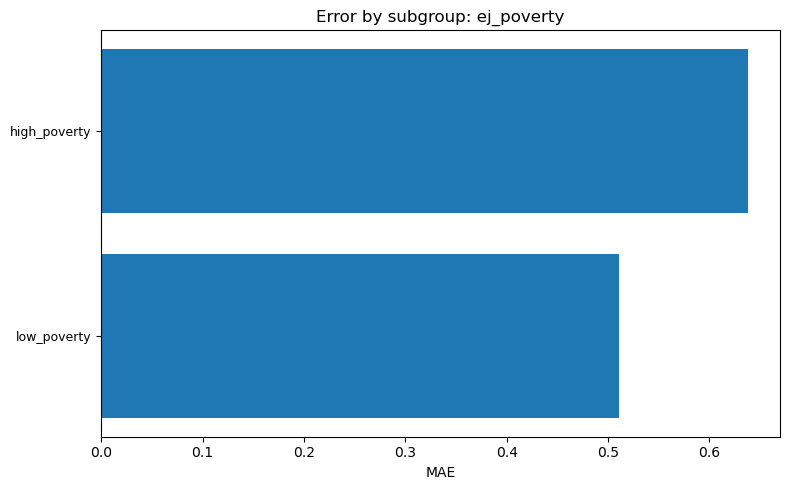

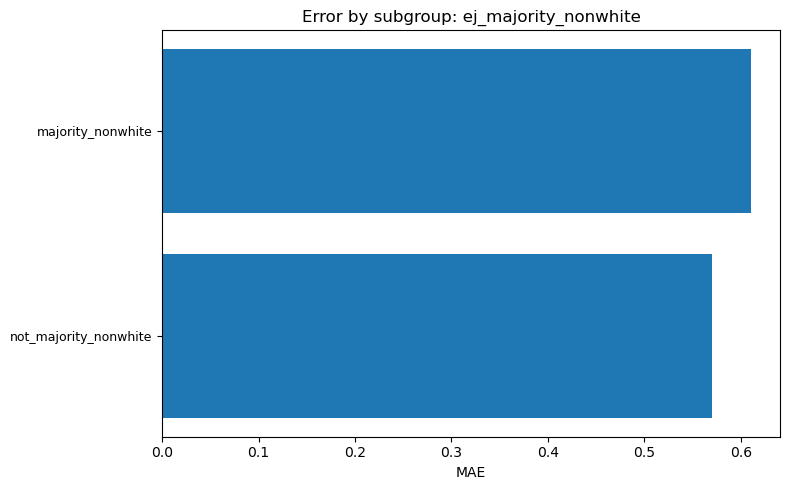

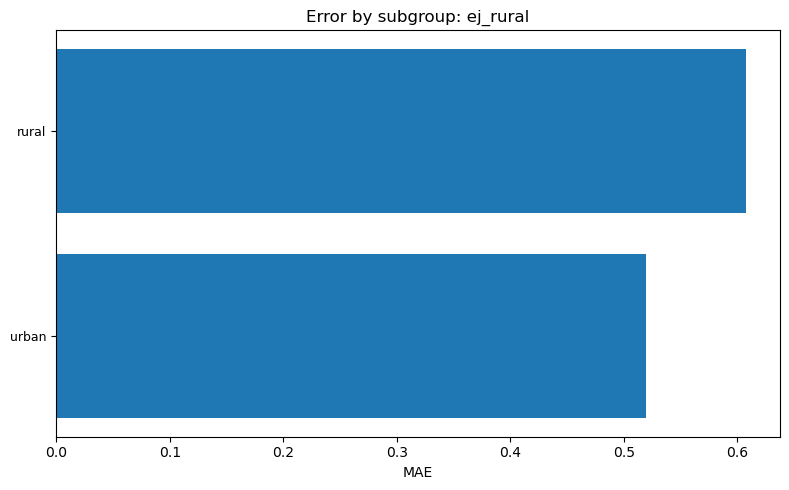

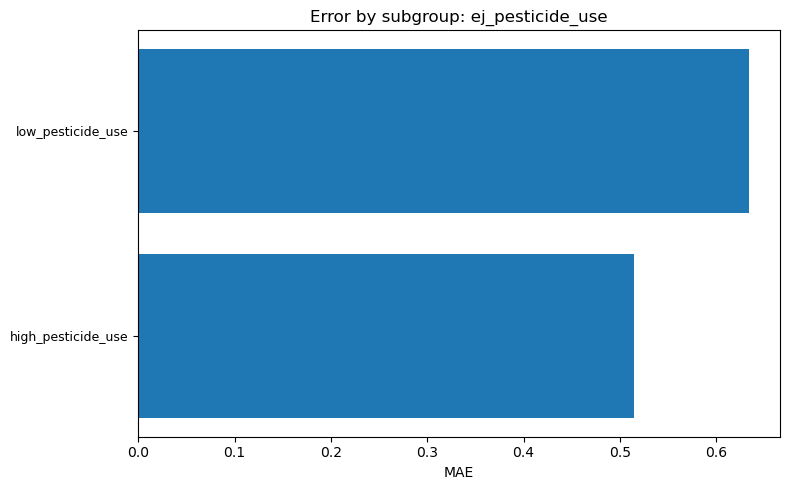

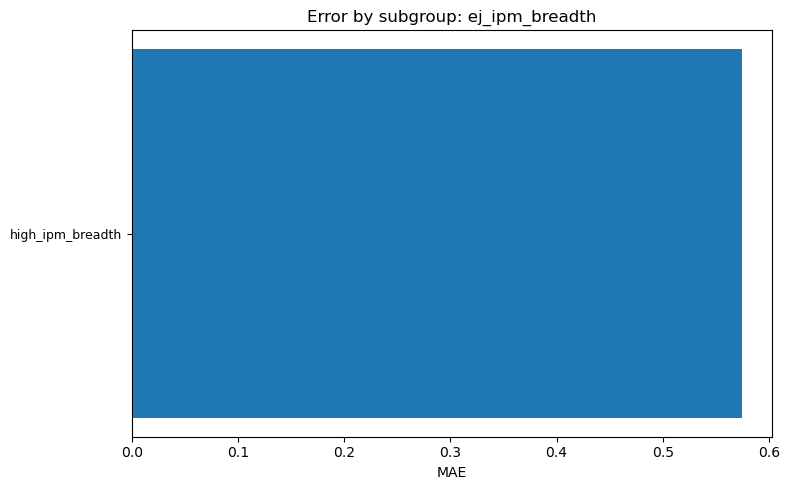

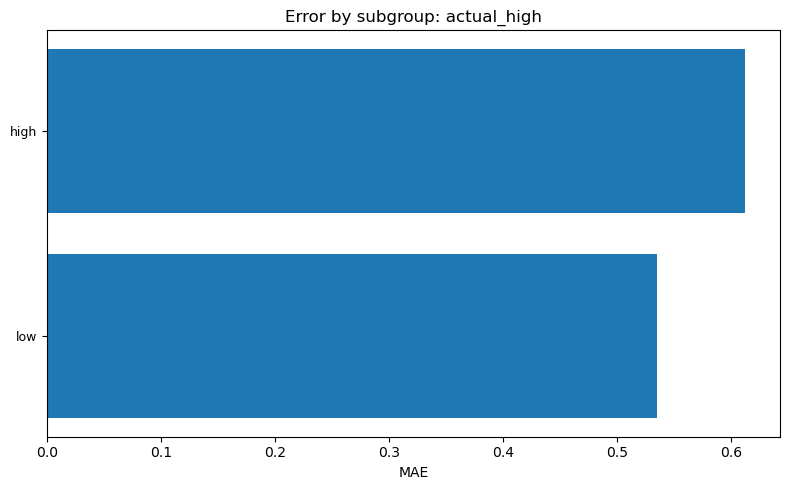

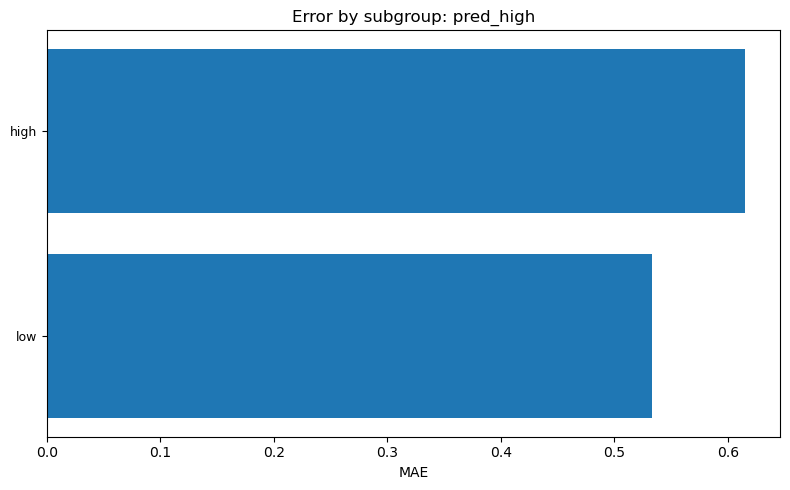

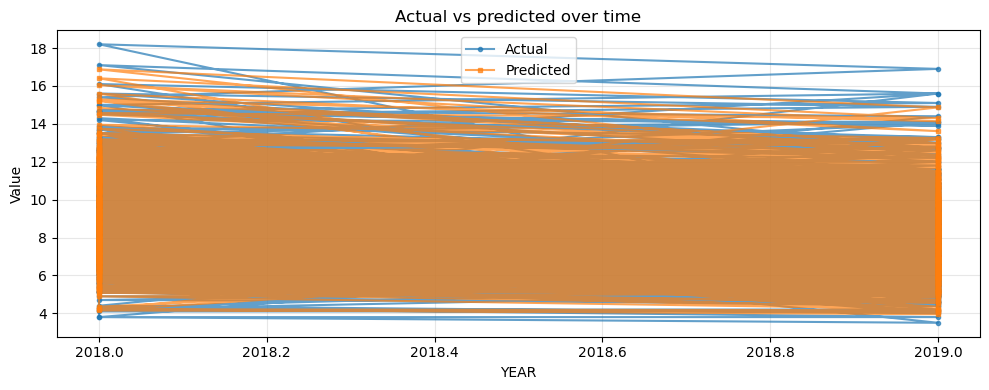


Subgroup performance

Subgroup: ej_poverty


,n,mean_actual,mean_predicted,MAE,RMSE,mean_residual,underprediction_rate,note
group,,,,,,,,
high_poverty,610,9.853770,9.871940,0.637719,0.844334,-0.018169,0.495082,
low_poverty,609,7.228243,7.297959,0.510940,0.676188,-0.069716,0.471264,



Subgroup: ej_majority_nonwhite


,n,mean_actual,mean_predicted,MAE,RMSE,mean_residual,underprediction_rate,note
group,,,,,,,,
majority_nonwhite,131,7.991603,8.218068,0.610206,0.823049,-0.226465,0.396947,
not_majority_nonwhite,1088,8.608364,8.630306,0.570069,0.757670,-0.021942,0.493566,



Subgroup: ej_rural


...


Subgroup: pred_high


,n,mean_actual,mean_predicted,MAE,RMSE,mean_residual,underprediction_rate,note
group,,,,,,,,
high,610,10.276066,10.300664,0.615342,0.824453,-0.024598,0.481967,
low,609,6.805255,6.868531,0.533355,0.700330,-0.063276,0.484401,



Top errors


,actual,predicted,residual,abs_residual,FIPS,YEAR
0,8.9,12.353619,-3.453619,3.453619,55078,2019
1,15.6,12.195751,3.404249,3.404249,29153,2019
2,16.9,13.613781,3.286219,3.286219,21095,2019
3,13.0,9.912789,3.087211,3.087211,47035,2019
4,8.6,11.436063,-2.836063,2.836063,26131,2019
5,10.8,13.443377,-2.643377,2.643377,55078,2018
6,18.2,15.592338,2.607662,2.607662,21095,2018
7,9.6,12.189577,-2.589577,2.589577,47169,2018
8,4.9,7.334748,-2.434748,2.434748,8055,2019
9,10.3,7.885110,2.414890,2.414890,12035,2019



Interpretation
1. Overall: R² = 0.885; RMSE = 0.765, MAE = 0.574. Model explains a substantial share of variance.
2. Bias: Mean residual = -0.044. Residuals are roughly centered.
3. Residuals: Residual spread does not strongly depend on predicted value.
4. Subgroups: Subgroup MAE varies; check tables for groups with high error or low support.
5. Trust: Use metrics, residual plots, and subgroup results to judge whether the model is stable and fair enough for deployment.

Next steps
• Investigate top-error rows for outliers or data issues.
• If heteroskedasticity is present, consider transforms or robust metrics.
• If subgroups differ sharply, consider stratified models or fairness constraints.
• Re-evaluate on a fresh holdout if possible.


In [10]:
# Run diagnostics per target (validation holdout)

for target, out_dir in out_dirs.items():
    print("\n" + "=" * 90)
    print(f"Target: {target}")
    print(f"Out dir: {out_dir}")

    pred_val = load_validation_predictions(Path(out_dir))
    print("Validation predictions:", pred_val.shape)
    display(pred_val.head())

    result = run_notebook_evaluation(pred_val)

    print("\nHeadline metrics")
    display(result["metrics"])

    print("\nCore diagnostic plots")
    # `evaluate` returns matplotlib Figure objects
    for fig, title in result.get("figures", []):
        fig.suptitle(f"{target} — {title}", y=1.02)
        plt.show(fig)

    if result.get("subgroup_tables"):
        print("\nSubgroup performance")
        for name, tbl in result["subgroup_tables"].items():
            print(f"\nSubgroup: {name}")
            display(tbl.sort_values("MAE", ascending=False).head(25))

    print("\nTop errors")
    display(result["top_errors"].head(25))

    print("\nInterpretation")
    print(result.get("interpretation", ""))
    print("\nNext steps")
    print(result.get("next_steps", ""))


In [11]:
# County-level error choropleths (mirrors model_evaluation.ipynb section 4b)
# Uses `predictions_all_counties.csv` written by the validation script.

import plotly.express as px

COUNTIES_GEOJSON_URL = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"

for target, out_dir in out_dirs.items():
    df = load_all_county_predictions(Path(out_dir)).copy()

    # Build per-county mean absolute error
    df["abs_residual"] = (df["actual"].astype(float) - df["prediction"].astype(float)).abs()
    county_error = (
        df.groupby(df["FIPS"].astype(str).str.zfill(5))
        .agg(mean_abs_error=("abs_residual", "mean"), n=("abs_residual", "count"))
        .reset_index()
        .rename(columns={"FIPS": "fips"})
    )

    # Worst/best sets (top/bottom 20% by mean error)
    q_high = county_error["mean_abs_error"].quantile(0.80)
    q_low = county_error["mean_abs_error"].quantile(0.20)
    county_error["error_bucket"] = np.where(
        county_error["mean_abs_error"] >= q_high,
        "worst_20pct",
        np.where(county_error["mean_abs_error"] <= q_low, "best_20pct", "middle"),
    )

    print("\n" + "=" * 90)
    print(f"County error maps — {target}")

    fig1 = px.choropleth(
        county_error,
        geojson=COUNTIES_GEOJSON_URL,
        locations="fips",
        color="mean_abs_error",
        color_continuous_scale="Reds",
        scope="usa",
        hover_data={"fips": True, "mean_abs_error": ":.3f", "n": True},
        title=f"Mean absolute prediction error by county ({target})",
    )
    fig1.update_layout(margin={"r": 0, "t": 50, "l": 0, "b": 0})
    fig1.show()

    fig2 = px.choropleth(
        county_error,
        geojson=COUNTIES_GEOJSON_URL,
        locations="fips",
        color="error_bucket",
        color_discrete_map={"worst_20pct": "#d7301f", "best_20pct": "#1a9850", "middle": "#cccccc"},
        scope="usa",
        hover_data={"fips": True, "mean_abs_error": ":.3f", "n": True},
        title=f"Worst / best prediction counties (top & bottom 20% by mean error) — {target}",
    )
    fig2.update_layout(margin={"r": 0, "t": 50, "l": 0, "b": 0})
    fig2.show()

    print("\nWorst counties (by mean_abs_error)")
    display(county_error.sort_values("mean_abs_error", ascending=False).head(15))
    print("\nBest counties (by mean_abs_error)")
    display(county_error.sort_values("mean_abs_error", ascending=True).head(15))



County error maps — CASTHMA



Worst counties (by mean_abs_error)


,fips,mean_abs_error,n,error_bucket
2734,49037,1.814242,2,worst_20pct
2675,48427,1.787084,2,worst_20pct
2576,48229,1.655119,2,worst_20pct
482,13259,1.437709,2,worst_20pct
2253,44007,1.381456,2,worst_20pct
1313,27075,1.374913,2,worst_20pct
1601,30085,1.343508,2,worst_20pct
2592,48261,1.294637,2,worst_20pct
1291,27031,1.221282,2,worst_20pct
507,13309,1.220599,2,worst_20pct



Best counties (by mean_abs_error)


,fips,mean_abs_error,n,error_bucket
549,16071,0.002296,2,best_20pct
192,06071,0.003708,2,best_20pct
187,06061,0.003765,2,best_20pct
1043,21175,0.004237,2,best_20pct
1341,27131,0.004450,2,best_20pct
362,13015,0.004985,2,best_20pct
2640,48357,0.006038,2,best_20pct
252,08073,0.006060,2,best_20pct
297,12017,0.006365,2,best_20pct
898,20095,0.007010,2,best_20pct



County error maps — COPD



Worst counties (by mean_abs_error)


,fips,mean_abs_error,n,error_bucket
2989,55078,3.048498,2,worst_20pct
1003,21095,2.946941,2,worst_20pct
1521,29153,2.329522,2,worst_20pct
2209,42053,2.262700,2,worst_20pct
1258,26131,2.162030,2,worst_20pct
1252,26119,2.153136,2,worst_20pct
1015,21119,2.141432,2,worst_20pct
1323,27095,2.071805,2,worst_20pct
2930,54071,2.065305,2,worst_20pct
2070,40001,2.058320,2,worst_20pct



Best counties (by mean_abs_error)


,fips,mean_abs_error,n,error_bucket
2874,53037,0.003413,2,best_20pct
180,06047,0.004423,2,best_20pct
2884,53057,0.007064,2,best_20pct
2214,42063,0.008504,2,best_20pct
2489,48055,0.009006,2,best_20pct
1770,36007,0.009951,2,best_20pct
2707,48491,0.010365,2,best_20pct
1692,31155,0.010511,2,best_20pct
2238,42111,0.013520,2,best_20pct
335,12095,0.014340,2,best_20pct
